# Validation Loss vs Number of Experiments
This notebook plots the validation loss across all the experiments carried out in Phase 1 and Phase 2.


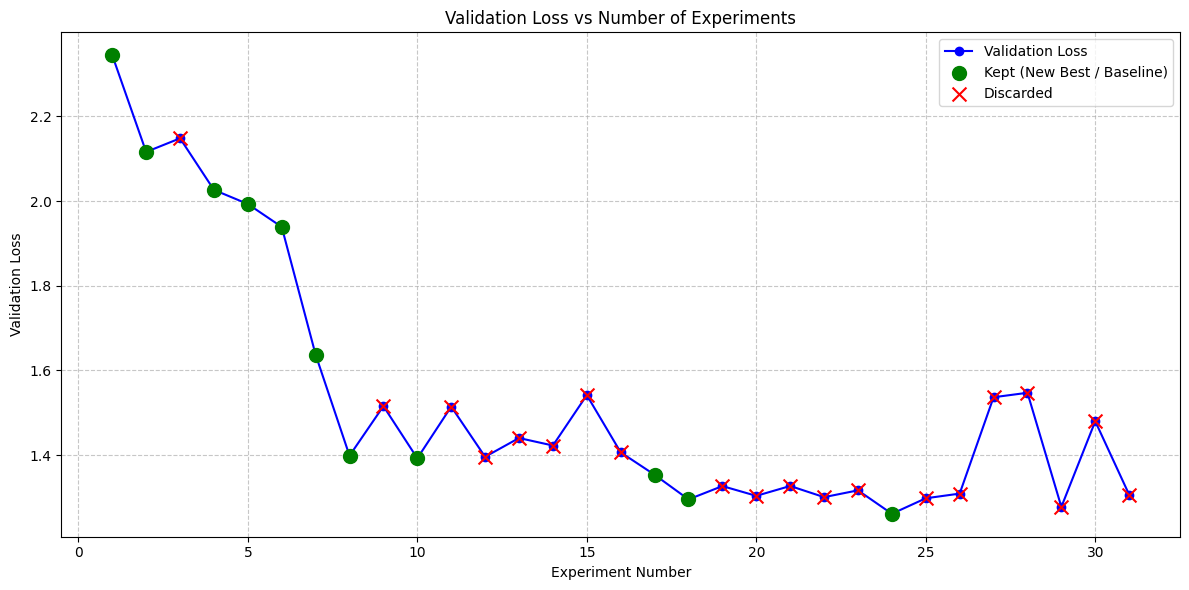

,experiment_number,loss,status,description
0,1,2.344449,keep,baseline ResNet50
1,2,2.116059,keep,num_epochs = 45
2,3,2.148212,discard,SiLU activation
3,4,2.026364,keep,GELU activation
4,5,1.993030,keep,weight decay 1e-3
5,6,1.938892,keep,remove Normalize
6,7,1.636959,keep,label_smoothing=0.0
7,8,1.398428,keep,pct_start=0.5
8,9,1.515510,discard,max_lr 1.5e-2
9,10,1.392258,keep,num_epochs=49


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv('results.tsv', sep='\t')
df['loss'] = pd.to_numeric(df['loss'], errors='coerce')
df.dropna(subset=['loss'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Add experiment numbers
df['experiment_number'] = range(1, len(df) + 1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['experiment_number'], df['loss'], marker='o', linestyle='-', color='b', label='Validation Loss')

# Highlight best models (Kept)
kept = df[df['status'] == 'keep']
plt.scatter(kept['experiment_number'], kept['loss'], color='g', zorder=5, s=100, label='Kept (New Best / Baseline)')

# Highlight discarded models
discarded = df[df['status'] == 'discard']
plt.scatter(discarded['experiment_number'], discarded['loss'], color='r', zorder=5, s=100, marker='x', label='Discarded')

plt.title('Validation Loss vs Number of Experiments')
plt.xlabel('Experiment Number')
plt.ylabel('Validation Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('loss_plot_final.png')
plt.show()

# Show dataframe
df[['experiment_number', 'loss', 'status', 'description']]
